# Compare LoRA / ReLoRA / SuperReLoRa

Reads runs from GPFS, builds the paper table, and saves figures (PDF+PNG) for the article.

**Expected layout**
```
/gpfs/gpfs0/timofey.glukhikh/SuperReLoRa/
├── runs/{lora,relora,superrelora}/
│   ├── loss_log.csv          # manual trainer
│   ├── logs/                 # HF Trainer TensorBoard
│   ├── trainer_state.json
│   ├── metrics.json          # optional (after eval)
│   └── DONE
└── figures/                  # output of this notebook
```

In [1]:
1

1

In [2]:
from __future__ import annotations

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# --- paths (override locally if needed) ---
PROJECT_ROOT = Path(
    os.environ.get(
        "SUPERRELORA_PROJECT_ROOT",
        "/gpfs/gpfs0/timofey.glukhikh/SuperReLoRa",
    )
)
RUNS_DIR = PROJECT_ROOT / "runs"
FIGURES_DIR = PROJECT_ROOT / "figures"
# Also copy into the LaTeX draft tree if it exists next to the repo
REPO_FIGURES = Path("../Draft_of_SuperReLoRa_Article_Timofey_Glukhikh/figures")

METHODS = ["lora", "relora", "superrelora"]
METHOD_LABELS = {
    "lora": "LoRA",
    "relora": "ReLoRA",
    "superrelora": "SuperReLoRa",
}
COLORS = {
    "lora": "#4C78A8",
    "relora": "#F58518",
    "superrelora": "#54A24B",
}

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("RUNS_DIR exists:", RUNS_DIR.is_dir())
print("FIGURES_DIR:", FIGURES_DIR)

PROJECT_ROOT: /gpfs/gpfs0/timofey.glukhikh/SuperReLoRa
RUNS_DIR exists: True
FIGURES_DIR: /gpfs/gpfs0/timofey.glukhikh/SuperReLoRa/figures


In [3]:
def save_fig(fig: plt.Figure, name: str) -> None:
    """Save PDF+PNG to GPFS figures/ and optionally to the article draft."""
    for folder in (FIGURES_DIR, REPO_FIGURES):
        folder.mkdir(parents=True, exist_ok=True)
        for ext in ("pdf", "png"):
            out = folder / f"{name}.{ext}"
            fig.savefig(out, bbox_inches="tight", dpi=200)
            print("wrote", out.resolve())


def load_loss_csv(run_dir: Path) -> pd.DataFrame | None:
    path = run_dir / "loss_log.csv"
    if not path.is_file():
        return None
    df = pd.read_csv(path)
    if "step" not in df.columns or "loss" not in df.columns:
        return None
    return df


def load_trainer_state_losses(run_dir: Path) -> pd.DataFrame | None:
    path = run_dir / "trainer_state.json"
    if not path.is_file():
        return None
    with open(path) as f:
        state = json.load(f)
    rows = []
    for entry in state.get("log_history", []):
        if "loss" in entry and "step" in entry:
            rows.append({"step": entry["step"], "loss": entry["loss"]})
    if not rows:
        return None
    return pd.DataFrame(rows)


def load_tensorboard_losses(run_dir: Path) -> pd.DataFrame | None:
    logdir = run_dir / "logs"
    if not logdir.is_dir():
        return None
    try:
        from tensorboard.backend.event_processing import event_accumulator
    except ImportError:
        print("tensorboard not installed; skip TB logs in", logdir)
        return None

    # HF Trainer may nest run folders under logs/
    event_dirs = [logdir]
    event_dirs += [p for p in logdir.iterdir() if p.is_dir()]

    for d in event_dirs:
        ea = event_accumulator.EventAccumulator(str(d))
        try:
            ea.Reload()
        except Exception:
            continue
        tags = ea.Tags().get("scalars", [])
        tag = next((t for t in ("train/loss", "loss") if t in tags), None)
        if tag is None:
            continue
        events = ea.Scalars(tag)
        return pd.DataFrame(
            {"step": [e.step for e in events], "loss": [e.value for e in events]}
        )
    return None


def load_train_curve(method: str) -> pd.DataFrame | None:
    run_dir = RUNS_DIR / method
    for loader in (load_loss_csv, load_trainer_state_losses, load_tensorboard_losses):
        df = loader(run_dir)
        if df is not None and len(df):
            df = df.sort_values("step").drop_duplicates("step")
            df["method"] = method
            return df
    return None


def load_metrics_json(method: str) -> dict:
    path = RUNS_DIR / method / "metrics.json"
    if path.is_file():
        with open(path) as f:
            return json.load(f)
    return {}


def run_status(method: str) -> str:
    d = RUNS_DIR / method
    if (d / "DONE").is_file():
        return "DONE"
    if (d / "final_model.pt").is_file() or (d / "final_model").is_dir():
        return "final_model"
    if d.is_dir():
        return "partial"
    return "missing"

## 1. Status of runs

In [4]:
status_rows = []
for m in METHODS:
    status_rows.append(
        {
            "method": METHOD_LABELS[m],
            "status": run_status(m),
            "run_dir": str(RUNS_DIR / m),
        }
    )
status_df = pd.DataFrame(status_rows)
status_df

,method,status,run_dir
0,LoRA,partial,/gpfs/gpfs0/timofey.glukhikh/SuperReLoRa/runs/...
1,ReLoRA,partial,/gpfs/gpfs0/timofey.glukhikh/SuperReLoRa/runs/...
2,SuperReLoRa,partial,/gpfs/gpfs0/timofey.glukhikh/SuperReLoRa/runs/...


## 2. Training loss curves

[warn] no train curve for lora
[warn] no train curve for relora
[warn] no train curve for superrelora


/tmp/ipykernel_2900726/1334723040.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


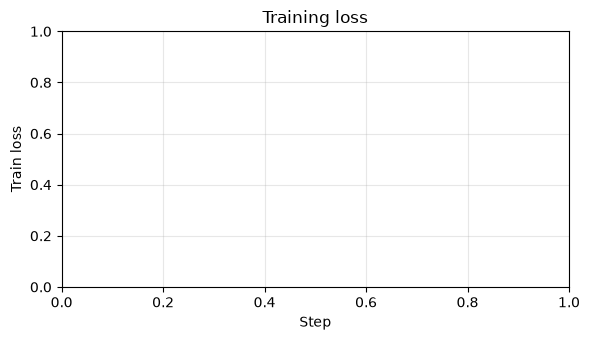

In [5]:
curves = {}
for m in METHODS:
    df = load_train_curve(m)
    if df is None:
        print(f"[warn] no train curve for {m}")
    else:
        curves[m] = df
        print(f"{m}: {len(df)} points")

fig, ax = plt.subplots(figsize=(6.0, 3.5))
for m, df in curves.items():
    ax.plot(
        df["step"],
        df["loss"],
        label=METHOD_LABELS[m],
        color=COLORS[m],
        linewidth=1.8,
    )
ax.set_xlabel("Step")
ax.set_ylabel("Train loss")
ax.set_title("Training loss")
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)
fig.tight_layout()
if curves:
    save_fig(fig, "loss_curves")
plt.show()

## 3. Metrics table (paper `tab:main`)

Fills from `metrics.json` if present; otherwise uses final train loss from the curve as a placeholder.

In [6]:
rows = []
for m in METHODS:
    metrics = load_metrics_json(m)
    final_train = None
    if m in curves and len(curves[m]):
        final_train = float(curves[m]["loss"].iloc[-1])
    rows.append(
        {
            "Method": METHOD_LABELS[m],
            "Train loss": metrics.get("train_loss", final_train),
            "Val PPL": metrics.get("val_ppl", metrics.get("perplexity")),
            "Acc": metrics.get("val_acc", metrics.get("accuracy")),
            "status": run_status(m),
        }
    )

table = pd.DataFrame(rows)
display(table)

# LaTeX snippet for the article
latex_path = FIGURES_DIR / "tab_main.tex"
cols = ["Method", "Train loss", "Val PPL", "Acc"]
latex = table[cols].to_latex(index=False, float_format="%.4f", na_rep="--")
latex_path.write_text(latex)
print("wrote", latex_path)
print(latex)

,Method,Train loss,Val PPL,Acc,status
0,LoRA,None,None,None,partial
1,ReLoRA,None,None,None,partial
2,SuperReLoRa,None,None,None,partial


wrote /gpfs/gpfs0/timofey.glukhikh/SuperReLoRa/figures/tab_main.tex
\begin{tabular}{llll}
\toprule
Method & Train loss & Val PPL & Acc \\
\midrule
LoRA & -- & -- & -- \\
ReLoRA & -- & -- & -- \\
SuperReLoRa & -- & -- & -- \\
\bottomrule
\end{tabular}



In [7]:
# Bar chart for available scalar metrics
plot_cols = []
for col, ylabel, fname in [
    ("Val PPL", "Validation perplexity", "val_ppl_bars"),
    ("Acc", "Token accuracy", "val_acc_bars"),
    ("Train loss", "Final train loss", "train_loss_bars"),
]:
    if table[col].notna().any():
        fig, ax = plt.subplots(figsize=(4.5, 3.2))
        vals = table[col].astype(float)
        ax.bar(
            table["Method"],
            vals,
            color=[COLORS[m] for m in METHODS],
            edgecolor="black",
            linewidth=0.6,
        )
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.grid(True, axis="y", alpha=0.3)
        fig.tight_layout()
        save_fig(fig, fname)
        plt.show()
        plot_cols.append(col)

if not plot_cols:
    print("No scalar metrics yet — run eval and write metrics.json into each run dir.")

No scalar metrics yet — run eval and write metrics.json into each run dir.


## 4. Mechanism plots (ReLoRA vs SuperReLoRa)

If training wrote `merge_log.csv` with columns `step,overlap,U_dim,delta_norm`, plot them here.
LoRA has no merges — skipped.

In [8]:
def load_merge_log(method: str) -> pd.DataFrame | None:
    path = RUNS_DIR / method / "merge_log.csv"
    if not path.is_file():
        return None
    return pd.read_csv(path)


merge_methods = ["relora", "superrelora"]
merge_logs = {m: load_merge_log(m) for m in merge_methods}

if any(df is not None for df in merge_logs.values()):
    # Overlap after reinit
    if any(df is not None and "overlap" in df.columns for df in merge_logs.values()):
        fig, ax = plt.subplots(figsize=(5.5, 3.2))
        for m, df in merge_logs.items():
            if df is None or "overlap" not in df.columns:
                continue
            x = df["cycle"] if "cycle" in df.columns else range(1, len(df) + 1)
            ax.plot(x, df["overlap"], marker="o", label=METHOD_LABELS[m], color=COLORS[m])
        ax.set_xlabel("Merge cycle")
        ax.set_ylabel(r"$\|W_A^\\top U\|_F$ after reinit")
        ax.set_title("Subspace overlap after reinit")
        ax.legend(frameon=False)
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        save_fig(fig, "overlap_vs_cycle")
        plt.show()

    # Accumulated basis size / effective rank proxy
    rank_col = next(
        (
            c
            for c in ("U_dim", "u_dim", "eff_rank")
            if any(df is not None and c in df.columns for df in merge_logs.values())
        ),
        None,
    )
    if rank_col:
        fig, ax = plt.subplots(figsize=(5.5, 3.2))
        for m, df in merge_logs.items():
            if df is None or rank_col not in df.columns:
                continue
            x = df["cycle"] if "cycle" in df.columns else range(1, len(df) + 1)
            ax.plot(x, df[rank_col], marker="o", label=METHOD_LABELS[m], color=COLORS[m])
        ax.set_xlabel("Merge cycle")
        ax.set_ylabel(rank_col)
        ax.set_title("Accumulated subspace size")
        ax.legend(frameon=False)
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        save_fig(fig, "rank_vs_cycle")
        plt.show()
else:
    print(
        "No merge_log.csv yet. After logging overlaps in train, re-run this cell.\n"
        "Expected columns: step,cycle,overlap,U_dim,delta_norm"
    )

No merge_log.csv yet. After logging overlaps in train, re-run this cell.
Expected columns: step,cycle,overlap,U_dim,delta_norm


## 5. How to plug figures into the article

```latex
\\begin{figure}[t]
\\centering
\\includegraphics[width=0.9\\linewidth]{figures/loss_curves.pdf}
\\caption{Training loss for LoRA, ReLoRA, and SuperReLoRa.}
\\label{fig:loss}
\\end{figure}
```

Copy PDFs from GPFS `figures/` into `Draft_of_SuperReLoRa_Article_Timofey_Glukhikh/figures/` (this notebook does that automatically when the draft path is reachable).

In [9]:
# Optional: write a tiny metrics.json template for eval to fill later
template = {
    "method": "METHOD",
    "train_loss": None,
    "val_ppl": None,
    "val_acc": None,
}
print(json.dumps(template, indent=2))
print("\nAfter eval, save as runs/<method>/metrics.json")

{
  "method": "METHOD",
  "train_loss": null,
  "val_ppl": null,
  "val_acc": null
}

After eval, save as runs/<method>/metrics.json
